# exploration of MSP summers and timing of Twin Cities Marathon dates
in light of the new start date news: https://www.mprnews.org/story/2026/07/07/twin-cities-marathon-to-move-later-in-the-fall-starting-2027-citing-hot-weather

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

In [2]:
## Threshold for MSP is 292.05C
292.05 - 273.15

18.900000000000034

In [3]:
input_path = "../../../Data/GHCND/msp_minnesota_summer_stats.csv"
df_summ = pd.read_csv(input_path)
df_summ


,Unnamed: 0,Year,SummerStart,SummerEnd,StartGrad,EndGrad,SummerLength,SummerAccHeat,SummerTmaxDay,SummerTavg
0,0,1961,165,243,0.205268,-0.146340,79,231.65,179,294.517722
1,1,1962,160,229,0.094240,-0.091589,70,117.60,179,293.053571
2,2,1963,162,244,0.197626,-0.127999,83,264.30,181,294.690361
3,3,1964,148,238,0.252824,-0.137940,91,334.00,213,294.718681
4,4,1965,162,231,0.134586,-0.155505,70,171.50,204,294.252143
...,...,...,...,...,...,...,...,...,...,...
58,58,2019,159,253,0.124908,-0.283768,95,304.10,200,295.018421
59,59,2020,152,245,0.225283,-0.223677,94,412.80,238,296.393617
60,60,2021,146,260,0.192252,-0.196772,115,533.40,156,296.270000
61,61,2022,150,254,0.256945,-0.165532,105,443.30,171,296.127143


In [3]:
df_summ.query("(Year <=1970)").SummerLength.mean()

np.float64(79.1)

In [4]:
df_summ.query("(Year >=2014)").SummerLength.mean()

np.float64(104.7)

In [5]:
df_summ.query("(Year > 1990) & (Year <= 2000)").SummerLength.mean()

np.float64(83.2)

In [6]:
df_summ.query("(Year >=2014)").SummerEnd.mean()

np.float64(254.2)

In [7]:
df_summ.query("(Year <=1970)").SummerEnd.mean()

np.float64(240.9)

In [8]:
df_summ.query("(Year >=2014)").SummerStart.mean()

np.float64(150.5)

In [10]:
df_summ.query("(Year <=1970)").SummerStart.mean()

np.float64(162.8)

In [12]:
df_summ.query("(Year > 1990) & (Year <= 2000)").SummerEnd.mean()

np.float64(242.3)

In [13]:
df_summ.query("(Year > 1990) & (Year <= 2000)").SummerStart.mean()

np.float64(160.1)

In [33]:
plt.style.use('default')

In [28]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

## create lollipop plot of start/end dates

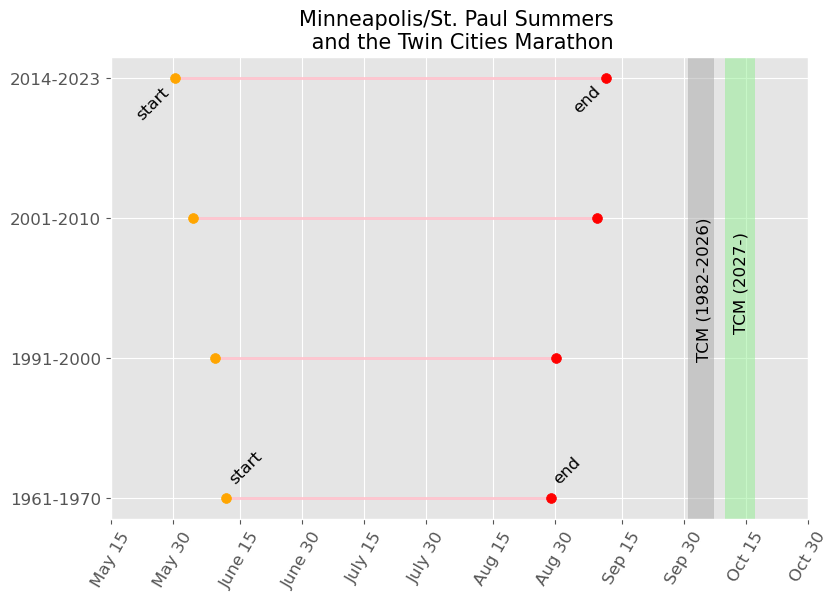

In [107]:
# Create a dataframe
yr_groups = ['1961-1970', 
             #'1971-1980', 
             #'1981-1990', 
             '1991-2000', '2001-2010', '2014-2023']

starts=[df_summ.query("(Year <=1970)").SummerStart.mean(),
        #df_summ.query("(Year > 1970) & (Year <= 1980)").SummerStart.mean(),
        #df_summ.query("(Year > 1980) & (Year <= 1990)").SummerStart.mean(),
       df_summ.query("(Year > 1990) & (Year <= 2000)").SummerStart.mean(),
        df_summ.query("(Year > 2000) & (Year <= 2010)").SummerStart.mean(),
       df_summ.query("(Year >=2014)").SummerStart.mean()]

ends=[df_summ.query("(Year <=1970)").SummerEnd.mean(),
     #df_summ.query("(Year > 1970) & (Year <= 1980)").SummerEnd.mean(),
        #df_summ.query("(Year > 1980) & (Year <= 1990)").SummerEnd.mean(),
       df_summ.query("(Year > 1990) & (Year <= 2000)").SummerEnd.mean(),
        df_summ.query("(Year > 2000) & (Year <= 2010)").SummerEnd.mean(),
       df_summ.query("(Year >=2014)").SummerEnd.mean()]

df = pd.DataFrame({'group':yr_groups, 'start':starts , 'end':ends })
 
# Reorder it following the values of the first value:
ordered_df = df.sort_values(by='group', ascending=True)
my_range=range(1,len(df.index)+1)
 
# The horizontal plot is made using the hline function
with plt.style.context('ggplot'):
    plt.figure(figsize=(9,6))
    plt.hlines(y=my_range, xmin=ordered_df['start'], xmax=ordered_df['end'], color='pink', alpha=0.9, zorder=1, linewidth=2) #linestyle=':',
    #plt.axvline(x = 277, linestyle='--',color='black', alpha = 0.7)
    plt.axvspan(274,280, color='darkgrey', alpha=0.5)
    plt.axvspan(283,290, color='lightgreen', alpha=0.5)
    plt.scatter(ordered_df['start'], my_range, color='orange', alpha=1, label='start', s=50)
    plt.scatter(ordered_df['end'], my_range, color='red', alpha=1 , label='end', s=50)
    #plt.legend()

    plt.annotate('TCM (1982-2026)', xy=(276, 2), rotation=90, fontsize=12)#, xytext=(0, 80)
    plt.annotate('TCM (2027-)', xy=(285, 2.2), rotation=90, fontsize=12)
    plt.annotate('start', xy=(starts[0],1.1), rotation=45, fontsize=12)
    plt.annotate('end', xy=(ends[0],1.1), rotation=45, fontsize=12)
    plt.annotate('start', xy=(starts[-1]-10,3.7), rotation=45, fontsize=12)
    plt.annotate('end', xy=(ends[-1]-8.4,3.75), rotation=45, fontsize=12)
    
    # Add title and axis names
    plt.yticks(my_range, ordered_df['group'], fontsize=12)
    plt.xticks([135,150,166,181,196,211,227,242,258,273,288,303],
              ['May 15','May 30','June 15','June 30','July 15','July 30','Aug 15','Aug 30','Sep 15','Sep 30','Oct 15','Oct 30'],
              rotation=60, fontsize=12)
    plt.title("Minneapolis/St. Paul Summers \n and the Twin Cities Marathon", loc='center', fontsize=15)
    plt.xlabel('')
    plt.ylabel('')
    
    # Show the graph
    plt.grid(visible=True, which='major', axis='both')
    plt.savefig("../../../Data/GHCND/Plots/msp_tcm.png",bbox_inches='tight')
plt.show()